**¿QUIÉNES SON NUESTROS CLIENTES MÁS VALIOSOS? UN ENFOQUE DE CLUSTERING PARA SUPERMERCADOS**

**Por: Lenin Hernando Pérez Padilla**

**Contexto del Problema: Un Desafío de Negocio**

El equipo de marketing del Supermercado FreshMart ha notado que sus campañas publicitarias actuales, enviadas masivamente a todos los clientes, tienen un ROI (Retorno sobre la Inversión) bajo. Este gasto es ineficiente porque no considera las diferencias en el comportamiento y las necesidades de los clientes. La gerencia ha solicitado una solución para optimizar la inversión en marketing y aumentar la tasa de conversión de las promociones.
Para abordar este problema, se propone utilizar los datos de las tarjetas de membresía del supermercado, correspondientes a agosto de 2023. Este conjunto de datos, con 200 registros, contiene información valiosa sobre los clientes en un período de tiempo clave:

* Edad
* Sexo
* Ingresos Anuales
* Puntuación de Gasto (Spending Score): Una métrica interna que refleja el nivel de compromiso y el historial de compras del cliente.

La misión es clara: utilizar estas variables para segmentar la base de clientes en grupos distintos y accionables. El objetivo final es proporcionar al equipo de marketing perfiles detallados de cada grupo, junto con recomendaciones específicas, para que puedan diseñar campañas publicitarias personalizadas y de alto impacto que demuestren el valor de una estrategia data-driven.

Los datos empleados para la segmentación se tomaron del siguiente enlace: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-Python

**Exploración y limpieza de datos**

Los pasos de esta fase son:

* Analizar la distribución de cada una de las variables. 
* Buscar valores atípicos, duplicados y nulos.
* Crear gráficos de dispersión para las diferentes parejas de variables.

Con base en ello, habrá una idea de cómo se ven los clústeres antes de aplicar cualquier algoritmo.

In [1]:
#Importar bibliotecas para análisis y visualización de datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Cargar datos
df = pd.read_csv('../011-A Python Jupyter Notebook/Mall_Customers.csv', index_col='CustomerID')
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


In [3]:
#Verificar los tipos de datos de cada columna y detectar posibles valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


El dataset posee cuatro columnas (variables de entrada). El género (Gender) es de tipo texto (object). Las demás columnas son de tipo numérico. Hay 200 registros. No hay datos nulos.

In [4]:
#Eliminar datos duplicados
df = df.drop_duplicates()
df = df.dropna()
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


El dataset no tiene valores duplicados.

In [5]:
#Resumen estadístico de las columnas numéricas
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


**Interpretaciones del resumen estadístico**

*1. Columna edad (Age)*

La Edad va de 18 a 70 años, por lo que el Supermercado FreshMart tiene una base de clientes muy diversa, desde adultos jóvenes hasta personas mayores.

Por otro lado, el cliente promedio tiene 39 años, pero la mediana es de 36 años, lo cual sugiere que la mitad de los clientes son menores de 36. 

A su vez, la desviación estándar de 14 años indica que hay una buena dispersión de edades y los cuartiles confirman que hay una porción significativa de clientes de todas las generaciones.

*2. Columna ingresos (Annual Income)*

Los ingresos de los clientes oscilan entre 15K y 137K. Esto indica que el supermercado no se limita a un solo nicho demográfico, sino que atrae a clientes de un espectro económico muy diverso, desde aquellos con ingresos más modestos hasta personas con alto poder adquisitivo.

Por su parte, el promedio (60,56K) y la mediana (61,50K) son muy cercanos entre sí. Esta similitud sugiere que la distribución de los ingresos es bastante simétrica, sin valores extremos que la distorsionen.

Además, la desviación estándar (26.26K) es relativamente alta, lo que confirma que hay una gran variedad en los ingresos de los clientes. Esto justifica la necesidad de un análisis de segmentación, ya que una única estrategia de marketing no funcionará para todos.

Con respecto al 50% central, la mitad de los clientes (el rango entre el cuartil 25% y el 75%) tiene ingresos entre 41.50K y 78.00K. Este es un grupo demográfico crucial para el supermercado, ya que representan la base de clientes más grande. 

Adicionalmente, el 25% de los clientes tiene ingresos inferiores a 41.50K, mientras que el otro 25% tiene ingresos superiores a 78.00K. Estos dos grupos extremos son de particular interés para el equipo de marketing, ya que podrían requerir estrategias y promociones muy diferentes.

*3. Columna puntuación de gasto (Spending Score)*

El puntaje se extiende desde un mínimo de 1.0 hasta un máximo de 99.0. Esto confirma que la métrica está funcionando como se espera, ya que captura a clientes que gastan o están comprometidos muy poco y a aquellos que son extremadamente activos y gastan mucho.

Por otro lado, el promedio (50.2) y la mediana (50.0) son prácticamente idénticos. Esto indica que, a diferencia de otras variables, la distribución de los puntajes de gasto es altamente simétrica y balanceada. En otras palabras, hay una cantidad similar de clientes con bajo gasto, alto gasto y gasto promedio.

Por su parte, la desviación estándar (25.8) es alta, ya que representa aproximadamente la mitad del promedio. Esta alta variabilidad confirma que la base de clientes es muy diversa en su comportamiento, haciendo que sea necesario implementar más de una estrategia.

Con respecto a los clientes de bajo gasto (25%), hay una cuarta parte que tiene un puntaje de gasto de 34.75 o menos. Este grupo necesita incentivos para gastar más, como cupones o promociones por volumen.

Adicionalmente, la otra cuarta parte de los clientes (alto gasto) tiene un puntaje de gasto de 73.0 o más. Este es un segmento de "Clientes Estrella" que necesitan programas de lealtad VIP o productos exclusivos para mantener su alto compromiso.

Finalmente, los clientes promedio (alrededor de 50 en el puntaje de gasto) representan el corazón de la base de clientes. Son la mayoría y representan el comportamiento de compra más común en el Supermercado FreshMart. Ya están gastando a un nivel sostenible, no son un riesgo de abandono inminente como los de gasto muy bajo, ni están gastando al máximo como los clientes estrella. Son los más susceptibles de ser "movidos" a un segmento superior (alto gasto). Pequeños incentivos pueden hacer que su gasto aumente significativamente, ofreciendo el mejor Retorno sobre la Inversión (ROI) en esfuerzos de marketing. Para este grupo, la meta del equipo de marketing debe ser clara: incentivar un aumento en la frecuencia y/o el volumen de la compra para convertirlos en clientes de alto valor. Se sugieren como estrategias de marketing campañas de incentivo por volumen, recomendación de productos premium o programas de lealtad "tier -based" (según sus gastos).

In [6]:
print(df['Gender'].unique())
print(df['Gender'].value_counts())

['Male' 'Female']
Gender
Female    112
Male       88
Name: count, dtype: int64


***Diagrama de barras para visualizar la columna Gender***

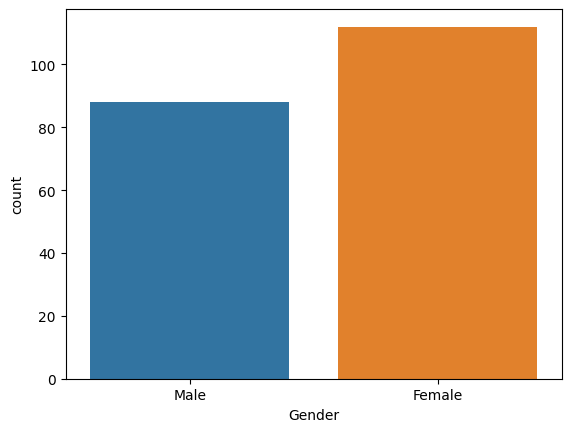

In [7]:
sns.countplot(x='Gender', data=df, hue='Gender')
plt.show()

***Diagramas de caja y bigote e histogramas***

1. Columnas Age y Gender

[Text(0.5, 1.0, 'Distribución de edades por sexo')]

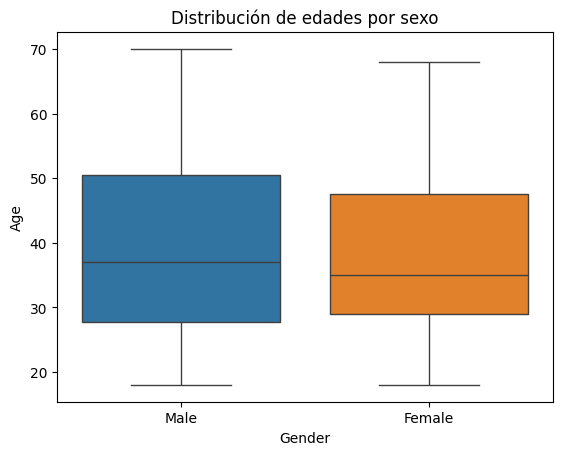

In [8]:
sns.boxplot(df, x='Gender', y='Age', hue='Gender').set(title='Distribución de edades por sexo')

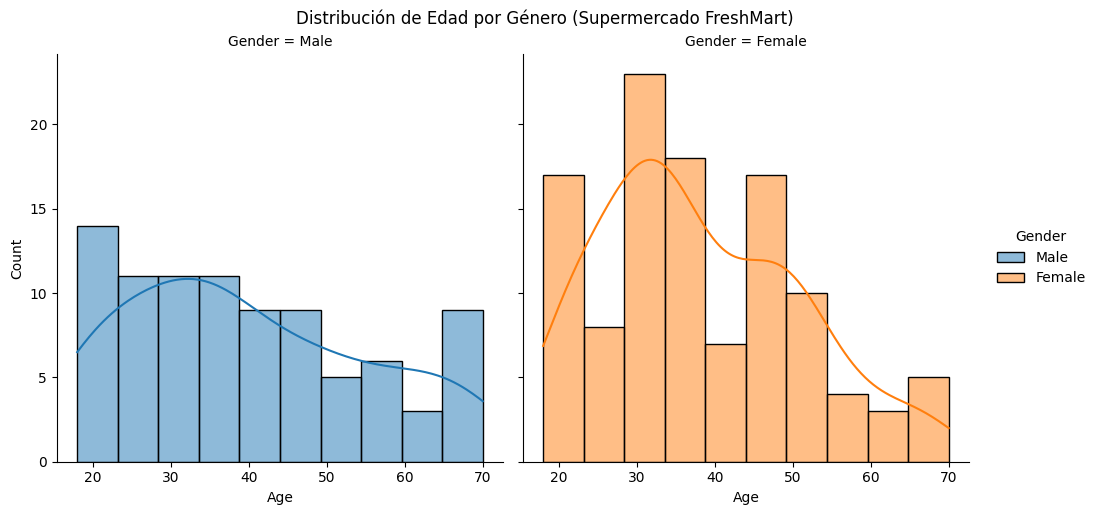

In [9]:
sns.displot(
    data=df,
    x="Age",
    col="Gender",  # Crea subgráficos por género
    hue="Gender", # Asigna un color diferente a cada subgráfico
    kind="hist", # Especifica el tipo de gráfico como histograma
    stat='count', #Para apreciar el número real de datos en cada contenedor
    bins=10, # Número de contenedores para agrupar los datos de edad
    kde=True # Añade una línea de densidad (útil para ver la forma de la distribución)
)

plt.suptitle('Distribución de Edad por Género (Supermercado FreshMart)', y=1.02)
plt.show()

2. Columnas Annual income y Gender

[Text(0.5, 1.0, 'Distribución de ingresos por sexo')]

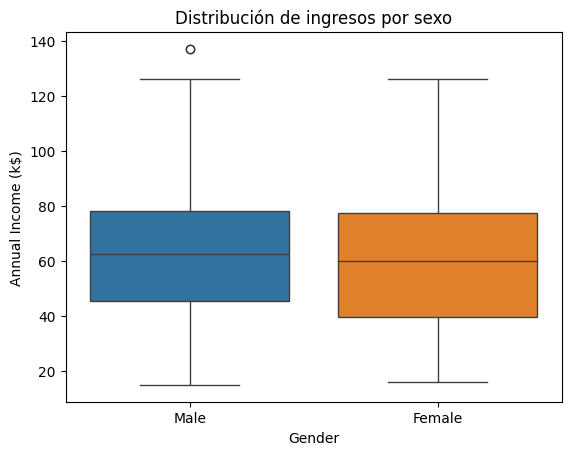

In [10]:
sns.boxplot(df, x='Gender', y='Annual Income (k$)', hue='Gender').set(title='Distribución de ingresos por sexo')

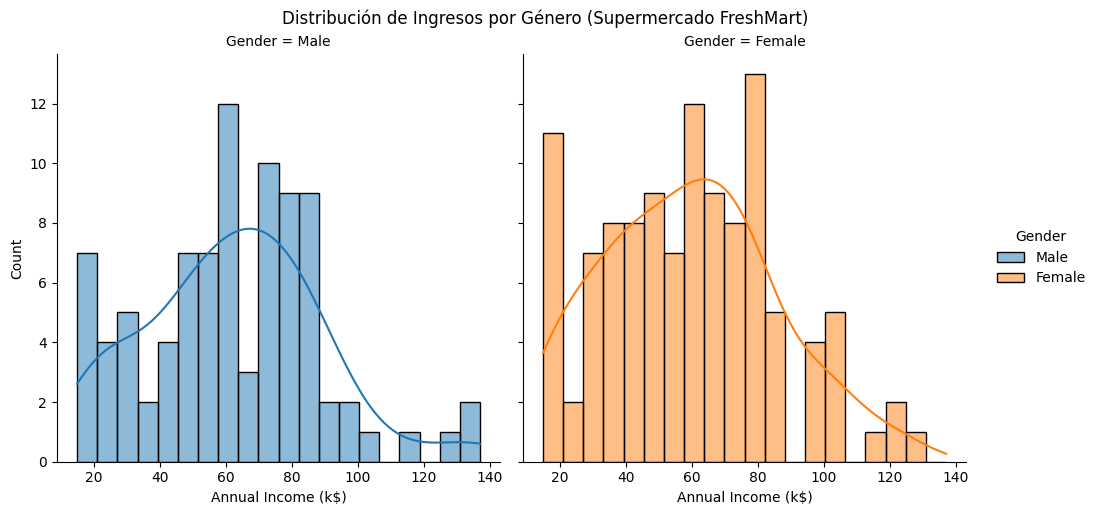

In [11]:
sns.displot(
    data=df,
    x="Annual Income (k$)",
    col="Gender",  # Crea subgráficos por género
    hue="Gender", # Asigna un color diferente a cada subgráfico
    kind="hist", # Especifica el tipo de gráfico como histograma
    stat='count', #Para apreciar el número real de datos en cada contenedor
    bins=20, # Número de contenedores para agrupar los datos de edad
    kde=True # Añade una línea de densidad (útil para ver la forma de la distribución)
)

plt.suptitle('Distribución de Ingresos por Género (Supermercado FreshMart)', y=1.02)
plt.show()

3. Columnas Spending score y Gender

[Text(0.5, 1.0, 'Distribución de puntajes por sexo')]

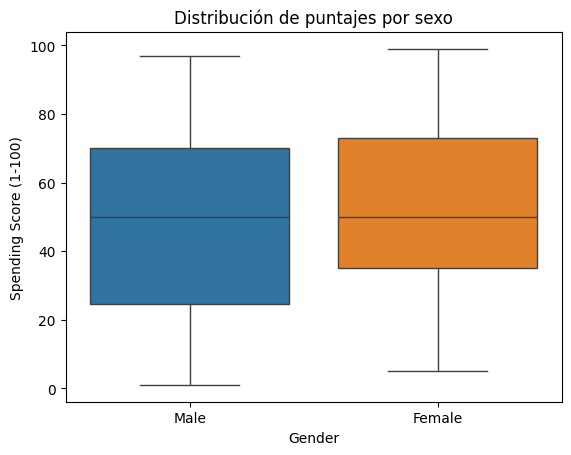

In [12]:
sns.boxplot(df, x='Gender', y='Spending Score (1-100)', hue='Gender').set(title='Distribución de puntajes por sexo')

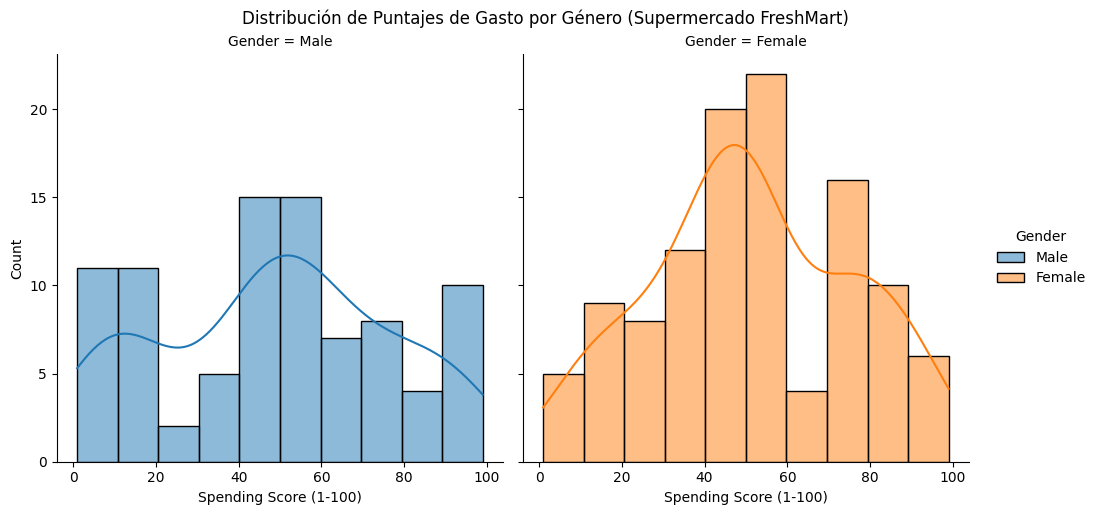

In [13]:
sns.displot(
    data=df,
    x="Spending Score (1-100)",
    col="Gender",  # Crea subgráficos por género
    hue="Gender", # Asigna un color diferente a cada subgráfico
    kind="hist", # Especifica el tipo de gráfico como histograma
    stat='count', #Para apreciar el número real de datos en cada contenedor
    bins=10, # Número de contenedores para agrupar los datos de edad
    kde=True # Añade una línea de densidad (útil para ver la forma de la distribución)
)

plt.suptitle('Distribución de Puntajes de Gasto por Género (Supermercado FreshMart)', y=1.02)
plt.show()

***Gráficos de dispersión***

1. Columnas Age y Annual income (Gender como leyenda)

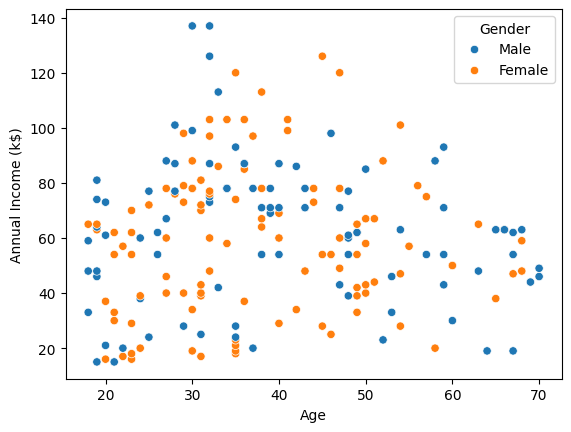

In [14]:
sns.scatterplot(x='Age', y='Annual Income (k$)', hue='Gender', data=df)
plt.show()

2. Columnas Age y Spending score (Gender como leyenda)

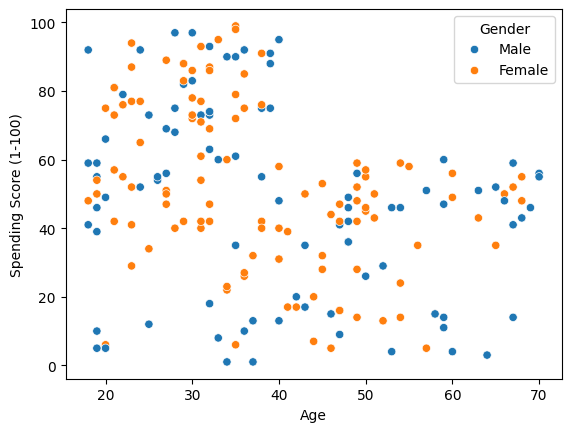

In [15]:
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Gender', data=df)
plt.show()

3. Columnas Annual income y Spending score (Gender como leyenda)

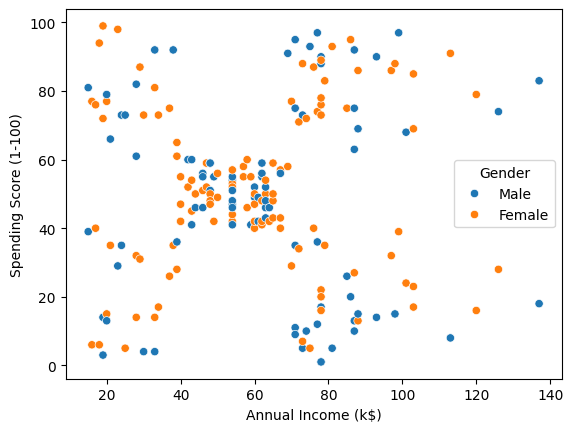

In [16]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender' ,data=df)
plt.show()

***Relaciones entre las distintas variables numéricas (Gender como leyenda)***

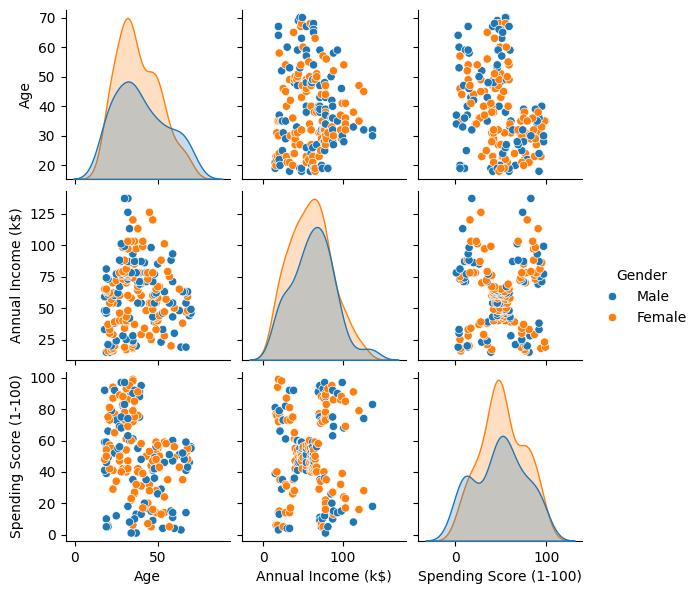

In [17]:
sns.pairplot(df, hue='Gender', height=2)

***Mapa de calor para examinar las correlaciones entre las variables***

Codificar columna Gender

In [18]:
sexo = {'Male': 0, 'Female': 1}
df['Gender'] = df['Gender'].map(sexo)

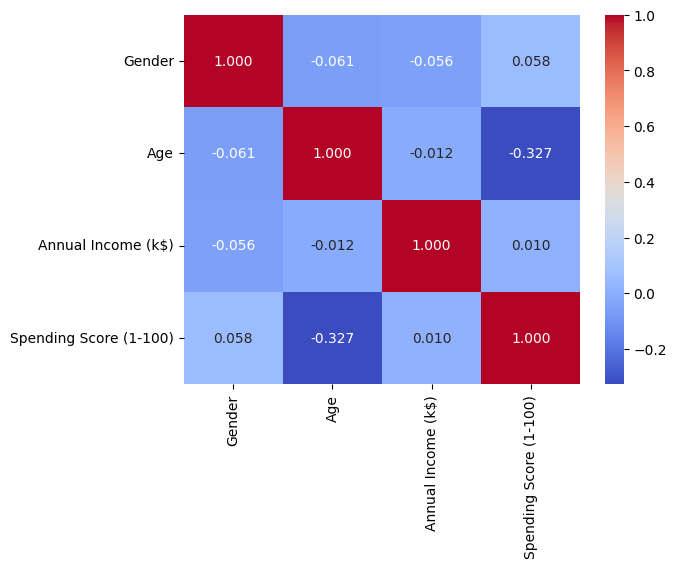

In [19]:
corr = np.corrcoef(df.T)
sns.heatmap(corr, xticklabels=df.columns, yticklabels=df.columns, cmap='coolwarm', annot=True, fmt='.3f')
plt.show()

Basado en el análisis exploratorio de datos y las correlaciones, la segmentación principal debe realizarse utilizando el Puntaje de Gasto (Spending score) y los Ingresos Anuales (Annual income) porque estas dos variables son las más críticas para definir el valor del cliente en el negocio y, lo que es fundamental para el modelo K-Means, su correlación lineal, **en valor absoluto,** es casi nula (r=0.010). Esta independencia garantiza que el modelo encuentre grupos que son distintivos tanto en su poder adquisitivo (Ingresos) como en su comportamiento de compra (Gasto). De esta forma, se identifican segmentos clave como los clientes de "alto ingreso/bajo gasto" (clientes con potencial de crecimiento) y los de "bajo ingreso/alto gasto" (clientes leales), permitiendo al equipo de marketing desarrollar estrategias de alto impacto que serían invisibles si se usaran variables altamente correlacionadas.

***Eliminar valores atípicos***

1. Columna Age

In [20]:
# Calcular promedio y desviación estándar
mean = df['Age'].mean()
std_dev = df['Age'].std()

# Calcular z-score para cada dato
z_score = (df['Age'] - mean) / std_dev

# Ajustar umbral de 3 desviaciones estándar
threshold = 3

# Remover datos atípicos del dataset
df = df[z_score <= threshold]

2. Columna Annual income

In [21]:
# Calcular promedio y desviación estándar
mean = df['Annual Income (k$)'].mean()
std_dev = df['Annual Income (k$)'].std()

# Calcular z-score para cada dato
z_score = (df['Annual Income (k$)'] - mean) / std_dev

# Ajustar umbral de 3 desviaciones estándar
threshold = 3

# Remover datos atípicos del dataset
df = df[z_score <= threshold]

3. Columna Spending score

In [22]:
# Calcular promedio y desviación estándar
mean = df['Spending Score (1-100)'].mean()
std_dev = df['Spending Score (1-100)'].std()

# Calcular z-score para cada dato
z_score = (df['Spending Score (1-100)'] - mean) / std_dev

# Ajustar umbral de 3 desviaciones estándar
threshold = 3

# Remover datos atípicos del dataset
df = df[z_score <= threshold]

In [23]:
#Conjunto de datos sin valores atípicos
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,0,19,15,39
2,0,21,15,81
3,1,20,16,6
4,1,23,16,77
5,1,31,17,40
...,...,...,...,...
196,1,35,120,79
197,1,45,126,28
198,0,32,126,74


**Preparación del modelo K-Means**

Como la correlación entre ingresos anuales (Annual Income) y puntaje de gasto (Spending Score) presenta el menor valor absoluto (r = 0.010), se opta por hacer el modelamiento K-Means con estas variables. Por lo tanto, se prepara un nuevo dataset que excluya a las columnas sexo (Gender) y edad (Age).

Para el desarrollo del modelo de clustering mediante el algoritmo K-means, se determinó prescindir de la división tradicional de los datos en conjuntos de entrenamiento (train) y validación (validation). Esta decisión se fundamenta bajo tres argumentos principales:

1) Naturaleza del Aprendizaje No Supervisado: A diferencia de los modelos supervisados, el algoritmo K-means no opera con variables objetivo o etiquetas predefinidas ($y$). Al no existir un valor real contra el cual contrastar una predicción (como el accuracy o el error cuadrático medio), la división de datos pierde su propósito primario de evaluar qué tan bien se adaptaría el modelo a datos completamente nuevos. El objetivo aquí es netamente exploratorio: descubrir la estructura intrínseca de los datos.

2) Tamaño de la Muestra ($N = 200$): Con un volumen total de 200 observaciones, realizar un fraccionamiento típico (por ejemplo, 80/20) resultaría en un conjunto de validación de apenas 40 registros. Estadísticamente, una muestra tan reducida posee una alta varianza y es altamente sensible a valores atípicos (outliers), lo que invalidaría la estabilidad de cualquier métrica calculada sobre ella. Mantener el 100% de los datos asegura que el algoritmo capture la densidad real de la distribución espacial.

3) Espacio Bidimensional de Baja Dimensionalidad ($D = 2$): Al contar con un espacio de características de solo dos columnas, el modelo está completamente exento de la "maldición de la dimensionalidad". La estructura geométrica puede ser validada de manera robusta y global utilizando el dataset completo mediante métodos de evaluación interna y técnicas de inspección visual directa (gráficos de dispersión).Por tanto, la validación de la calidad y el número óptimo de clústeres ($K$) se realizará de manera interna sobre la totalidad de la población ($N = 200$), empleando el Método del Codo (Inercia) y el Coeficiente de Silueta, aproximación metodológicamente estándar para escenarios de analítica descriptiva con muestras compactas.

*Referencia: Tan, P. N., Steinbach, M., & Kumar, V. (2016). Introduction to Data Mining (2nd ed.), Chapter 7, Edit Pearson*

In [24]:
#Preparación nuevo dataset únicamente con las columnas Annual income y spending score
df_new = df.drop(['Gender', 'Age'], axis=1)
df_new

,Annual Income (k$),Spending Score (1-100)
CustomerID,,
1,15,39
2,15,81
3,16,6
4,16,77
5,17,40
...,...,...
196,120,79
197,126,28
198,126,74


De acuerdo con las estadísticas descriptivas y la naturaleza de cada columna, es necesario estandarizar los datos, ya que las variables están en diferentes escalas.

In [25]:
#Como el dataset no tiene valores atípicos, se opta por trabajar con StandardScaler
from sklearn.preprocessing import StandardScaler

In [26]:
#Escalado de cada subconjunto
scaler = StandardScaler()
X = df_new.copy()
X_train = scaler.fit_transform(X)

**Optimización del modelo K-Means con el método del codo y el gráfico de Silhouette**

Se importa el modelo de clusterización K-Means

In [27]:
from sklearn.cluster import KMeans

Este fragmento de código representa el método del codo para determinar el valor de k más óptimo que permite modelar el dataset. Se obtiene una lista que relaciona el número de clusters (de 1 a 10) y la inercia.

In [28]:
inercia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, random_state = 42)
    kmeans.fit(X_train)
    inercia.append(kmeans.inertia_)

Ahora se grafica la lista obtenida del fragmento anterior.

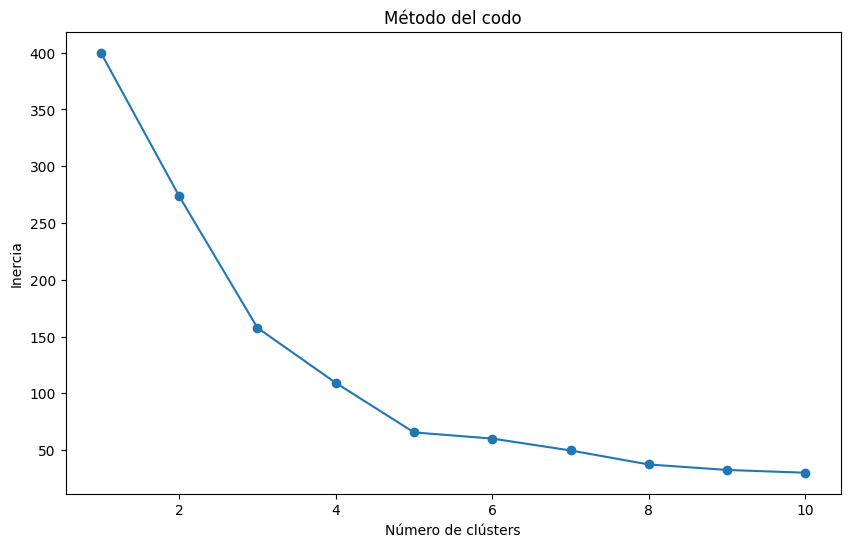

In [29]:
plt.figure(figsize = [10,6])
plt.title('Método del codo')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.plot(list(range(1, 11)), inercia, marker = 'o')
plt.show()

De acuerdo con la gráfica, el cambio más drástico en las pendientes se presenta cuando el número de clústers (k) es cinco. Para corroborar esta elección, se va a hacer un gráfico que involucra el puntaje de Silhouette y el número de clústers.

In [30]:
#Importar la métrica del puntaje de Silhouette
from sklearn import metrics

Este fragmento de código representa una lista que relaciona el número de clusters (de 2 a 10) y el puntaje de Silhouette para determinar el valor de k más óptimo que permite modelar el dataset.

In [31]:
sil_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, random_state = 42)
    cluster_labels = kmeans.fit_predict(X_train)
    score = metrics.silhouette_score(X_train, cluster_labels)
    sil_scores.append(score)

A continuación se grafica la lista obtenida del fragmento anterior.

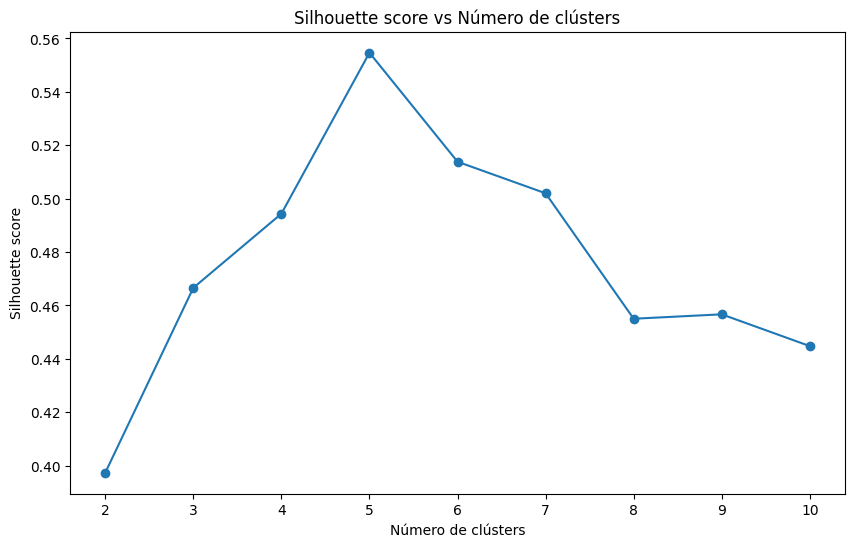

In [32]:
plt.figure(figsize = [10,6])
plt.plot(list(range(2, 11)), sil_scores, marker = 'o')
plt.title('Silhouette score vs Número de clústers')
plt.xlabel('Número de clústers')
plt.ylabel('Silhouette score')
plt.show()

De acuerdo con el método del codo y con el gráfico de Silhouette, el número óptimo de clusters es 5, con un puntaje de Silhouette cercano a 0.55

***Entrenamiento del modelo con el número de clusters óptimo (5)***

In [33]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
kmeans.fit(X_train)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


***Presentación de los centroides y etiquetas***

In [34]:
centroides = kmeans.cluster_centers_
centroides

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

Estos valores de los centroides corresponden al conjunto de datos ya escalado. Para realizar el gráfico que incluya los datos ya segmentados y con todos los componentes necesarios, es necesario usar los valores originales de ingresos y puntajes de gasto (o sea sin estandarizar)). Por lo tanto, es necesario desescalar los valores de los centroides.

In [35]:
etiquetas = kmeans.labels_
etiquetas

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

Estos son los valores de las etiquetas para cada registro del conjunto de entrenamiento.

Estos valores son las etiquetas del conjunto de la muestra aleatoria.

**Gráficos de los clusteres obtenidos con el número óptimo de clústeres (k = 5)**

Se añaden las etiquetas obtenidas del conjunto de entrenamiento al dataset de entrenamiento sin escalar.

In [36]:
df['Cluster'] = etiquetas
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
CustomerID,,,,,
1,0,19,15,39,4
2,0,21,15,81,2
3,1,20,16,6,4
4,1,23,16,77,2
5,1,31,17,40,4
...,...,...,...,...,...
196,1,35,120,79,1
197,1,45,126,28,3
198,0,32,126,74,1


Conversión de los centroides a las escalas originales de ingresos anuales y puntaje de gasto.

In [37]:
#Utiliza el método inverse_transform() del objeto scaler para desescalar los centroides
centroides_desescalados = scaler.inverse_transform(centroides)
#Convertir centroides_desescalados a dataframe para el análisis e interpretación
df_centroides = pd.DataFrame(
    data=centroides_desescalados,
    columns=['Ingreso Anual Promedio (K$)', 'Puntaje de Gasto Promedio (1-99)']
)
#Añadir el número de clúster para la tabla de reporte (K=5)
df_centroides.index = ['Clúster ' + str(i) for i in df_centroides.index]
# Imprimir el resultado final
print(df_centroides)

           Ingreso Anual Promedio (K$)  Puntaje de Gasto Promedio (1-99)
Clúster 0                    55.296296                         49.518519
Clúster 1                    86.538462                         82.128205
Clúster 2                    25.727273                         79.363636
Clúster 3                    88.200000                         17.114286
Clúster 4                    26.304348                         20.913043


Se añaden las etiquetas de la muestra aleatoria al dataset original de la muestra aleatoria sin escalar.

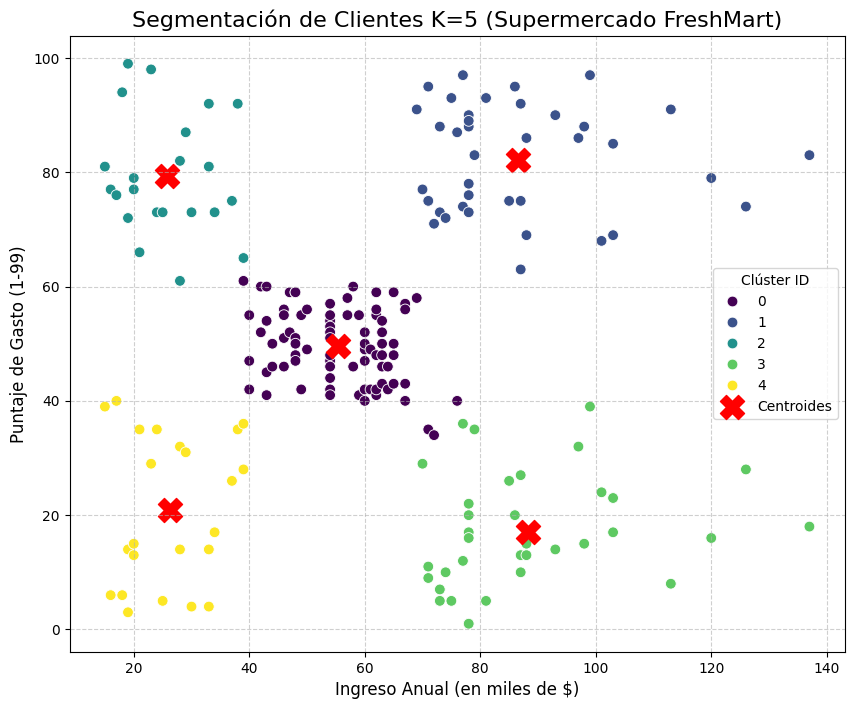

In [38]:
#Preparación del gráfico
#Los centroides desescalados se almacenan como un arreglo
array_centroides = np.array(centroides_desescalados)

#Tamaño del gráfico
plt.figure(figsize=(10, 8))

# A. Gráfico de Dispersión: conjunto de datos de entrenamiento
sns.scatterplot(
    data=df,
    x='Annual Income (k$)', #Variable que va en el eje X (Ingresos anuales)
    y='Spending Score (1-100)', #Variable que va en el eje Y (Puntaje de gasto)
    hue='Cluster',        # Color según la etiqueta de clúster
    palette='viridis',             # Paleta de colores distintivos
    s=60,                       # Tamaño de los puntos
    legend='full',              # Mostrar la leyenda de clústeres
    alpha=1                   # Transparencia para ver la densidad de puntos
)

# B. Puntos de los Centroides (los centros de cada clúster)
plt.scatter(
    x=array_centroides[:, 0],          # Ingreso Anual (Columna 0 del array)
    y=array_centroides[:, 1],          # Puntaje de Gasto (Columna 1 del array)
    s=300,                       # Tamaño grande para que se vean
    c='red',                     # Color rojo para resaltarlos
    marker='X',                  # Marcador en forma de 'X' o estrella
    label='Centroides'           #Etiquetas para los centroides
)

# Etiquetas, títulos y cuadrículas
plt.title(f'Segmentación de Clientes K={len(centroides)} (Supermercado FreshMart)', fontsize=16)
plt.xlabel('Ingreso Anual (en miles de $)', fontsize=12)
plt.ylabel('Puntaje de Gasto (1-99)', fontsize=12)
plt.legend(title='Clúster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [39]:
edad_promedio_cluster = df.groupby('Cluster')['Age'].mean().round(1)
print("--- Edad Promedio por Clúster ---")
print(edad_promedio_cluster)

--- Edad Promedio por Clúster ---
Cluster
0    42.7
1    32.7
2    25.3
3    41.1
4    45.2
Name: Age, dtype: float64


In [40]:
proporcion_mujeres = df.groupby('Cluster')['Gender'].mean().round(2) * 100
proporcion_hombres = 100 - proporcion_mujeres
df_proporciones = pd.DataFrame({
    'Mujeres (%)': proporcion_mujeres,
    'Hombres (%)': proporcion_hombres
})
print("\n--- Proporción de Sexo por Clúster ---")
print(df_proporciones)


--- Proporción de Sexo por Clúster ---
         Mujeres (%)  Hombres (%)
Cluster                          
0               59.0         41.0
1               54.0         46.0
2               59.0         41.0
3               46.0         54.0
4               61.0         39.0


**Estrategias de marketing**

De acuerdo con el gráfico  se aprecia una clara separación de los grupos en el plano Puntaje de Gasto vs. Ingreso Anual que valida la decisión de usar estas dos variables y demuestra el éxito del modelo K-Means. La estructura visible del gráfico revela cinco tipos de clientes con estrategias de marketing bien diferenciadas, que se sustentan con los cálculos de promedios y proporciones agrupando por cluster:

**1) Cluster 0 — Ingreso medio, gasto medio**

*El cliente equilibrado y racional* 

Perfil analítico: Ingresos: ~$55k. Puntaje: ~49. Promedio de edad 42,7. Distribución: 59% mujeres, 41% hombres.

El segmento más numeroso. Compran con cabeza, comparan precios y valoran la relación calidad-precio. Son fidelizables si se les demuestra valor consistente.

Campaña: "Inteligente es saber cuándo vale la pena"

*"Productos de calidad real, a precios que tienen sentido. Sin trucos, sin letra pequeña. Porque gastar bien es una decisión inteligente, y tú ya lo sabes."*

Canales: Google Ads, comparadores de precios, programas de puntos, email con recomendaciones personalizadas, reseñas y ratings destacados.

**2) Cluster 1 — Alto ingreso, alto puntaje de gasto**

*El cliente premium ideal*

Perfil analítico: Ingresos: ~$86k. Puntaje: ~82. Promedio de edad: 32,7. Distribución: 54% mujeres, 46% hombres.

El segmento más valioso. Pueden y quieren gastar. Buscan calidad, exclusividad y experiencia de marca.

Campaña: "Porque tu estilo no tiene precio, pero sí tiene nombre"

*"Acceso anticipado a colecciones exclusivas. Servicio personalizado. Beneficios que solo existen para quienes entienden que la diferencia está en los detalles. Bienvenido a la membresía élite."*

Canales: email marketing personalizado, programas de fidelización VIP, eventos privados, publicidad en medios premium, atención al cliente dedicada.

**3) Cluster 2 — Bajo ingreso, alto puntaje de gasto**

*El comprador impulsivo y aspiracional*

Perfil analítico: Ingresos: ~$26k. Puntaje: ~79. Promedio de edad: 25,3. Distribución: 59% mujeres, 41% hombres.

Gastan más de lo que "deberían" según su nivel socioeconómico. Probablemente jóvenes, estudiantes o personas que priorizan la experiencia sobre el ahorro.

Campaña: "Date el lujo que mereces"

*"No necesitas ganar más para vivir mejor. Nuestras ofertas flash y planes de pago flexibles hacen que lo que deseas esté siempre al alcance de tu mano. Compra hoy, celebra hoy."*

Canales: redes sociales (TikTok, Instagram Reels), influencers de nivel medio, cuotas sin interés, descuentos por tiempo limitado.

**4) Cluster 3 — Alto ingreso, bajo puntaje de gasto**

*El ahorrador cauteloso o el cliente no conquistado*

Perfil analítico: Ingresos: ~$88k. Puntaje: ~17. Promedio de edad: 41,1. Distribución: 46% mujeres, 54% hombres.

Tienen el dinero pero no lo gastan aquí (o en general). Pueden ser conservadores financieros, desconfiados de la marca, o simplemente no han encontrado la propuesta de valor correcta. Son el mayor potencial sin explotar.

Campaña: "Ya lo tienes todo. Ahora disfrútalo."

*"Has trabajado duro para llegar hasta aquí. Es momento de recompensarte. Descubre por qué miles de personas como tú ya confían en nosotros: garantía extendida, devolución sin preguntas y asesoría personalizada incluida."*

Canales: remarketing segmentado, testimonios de pares (social proof de alto poder adquisitivo), muestras gratuitas o experiencias de prueba sin compromiso, enfoque en seguridad y garantía.

**5) Cluster 4 — Bajo ingreso, bajo puntaje de gasto**

*El cliente austero o de subsistencia*

Perfil analítico: Ingresos: ~$26k. Puntaje: ~21. Promedio de edad: 45,2. Distribución: 61% mujeres, 39% hombres.

Gastan poco y tienen recursos limitados. No son el foco principal de rentabilidad inmediata, pero pueden ser fidelizados a largo plazo con propuestas de valor accesibles.

Campaña: "Lo esencial, al mejor precio. Siempre."

*"Sabemos que cada peso cuenta. Por eso tenemos lo que necesitas, sin extras que no pediste. Precios claros, calidad garantizada y siempre cerca de ti. Porque cuidarte no debería costar una fortuna."*

Canales: volantes físicos y presencia local, WhatsApp Business, combos y paquetes de ahorro, programa de referidos, app con cupones semanales.

**Ampliación del análisis estratégico**

**1) Clúster 0 - Equilibrado racional.** Este es el segmento más subestimado estratégicamente. Por ser "el del medio", los equipos de marketing tienden a ignorarlo. Sin embargo, su volumen lo convierte en la columna vertebral del negocio: es el que sostiene el flujo de caja constante y predecible. La clave aquí no es aumentar el ticket individual, sino aumentar la frecuencia y el cross-sell (identificar necesidades adicionales del cliente y proponer productos o servicios que las satisfagan, incrementando el agrado y fomentando la fidelización.). Si logras que cada cliente de este clúster compre una categoría adicional por visita, el impacto en ingresos puede superar fácilmente al de una campaña enfocada en el cluster 2. Son altamente susceptibles a la evidencia social (reseñas, ratings, "los más vendidos") y a los bundles inteligentes que les hagan sentir que están tomando la decisión más racional. El mayor riesgo aquí es el estancamiento: si no se trabaja activamente, este cluster permanece plano indefinidamente.

**2) Clúster 1 — Premium ideal.** Este es el segmento que debe ser protegido a cualquier costo. La regla del 80/20 de Pareto se cumple aquí con rigor: este cluster, siendo relativamente pequeño en número de clientes, probablemente representa la mayor parte del margen operativo de la tienda.
El error más común con clientes de alto valor es tratarlos igual que a todos los demás, lo que los hace sentir invisibles y los empuja a competidores. La estrategia correcta es la hiper-personalización: historial de compras analizado para recomendaciones proactivas, comunicaciones firmadas por un asesor con nombre, invitaciones a pre-lanzamientos. El LTV (Lifetime Value) de este cluster puede ser 5 a 10 veces el de los demás. Invertir el 30-40% del presupuesto de retención aquí es completamente justificable desde el análisis de cohortes.

**3) Cluster 2 — Impulsivo aspiracional.** El principal riesgo de este segmento es su fragilidad financiera. Su alto puntaje de gasto no refleja riqueza sino una disposición conductual a gastar más allá de sus medios, lo que lo hace extremadamente sensible a cambios en su situación económica (desempleo, deudas, cambios de vida). El churn en este cluster no siempre es voluntario: muchas veces el cliente simplemente "ya no puede". La estrategia correcta es maximizar el valor en el corto y mediano plazo sin generar dependencia de deuda que deteriore la relación. Los modelos Buy Now Pay Later (BNPL) son un arma de doble filo: aumentan la conversión inmediata pero elevan el riesgo de morosidad y abandono posterior. Lo ideal es combinar urgencia (ofertas flash, contadores regresivos) con gamificación que premie la recurrencia sin exigir tickets altos. Un programa de puntos por frecuencia, no por monto, puede fidelizarlos sin presionar su bolsillo.

**4) Cluster 3 — Ahorrador sin conquistar.** Este es el mayor diamante sin pulir de todo el análisis. Desde el punto de vista del dato, es el cluster más parecido al 1 en capacidad económica, pero con un comportamiento de gasto completamente opuesto. Eso significa que el problema no es el dinero, es la percepción de valor o la desconfianza. Los perfiles típicos de este cluster son personas conservadoras financieramente (ahorradores estructurales), personas quemadas por malas experiencias previas de compra, o simplemente clientes que aún no han encontrado el argumento correcto para gastar aquí. La estrategia de activación debe eliminar el riesgo percibido: devoluciones sin preguntas, pruebas gratuitas, garantías largas, y testimonios de pares con perfiles similares (no influencers, sino personas reales con poder adquisitivo equivalente). Una vez activados, tienen altísima probabilidad de migrar hacia el comportamiento del cluster 1, lo que hace que el costo de adquisición se amortice ampliamente a lo largo del tiempo.

**5) Cluster 4 — Austero de subsistencia.** Desde una óptica de ROI inmediato, la inversión publicitaria en este cluster tiene el retorno más bajo de los cinco. Sin embargo, descartarlo completamente es un error estratégico de largo plazo por dos razones. Primera: la movilidad social es real. Un porcentaje de estos clientes mejorará su situación económica y, si tienen una relación positiva con la marca desde antes, migrarán naturalmente hacia el cluster 0 o incluso el 2, siendo fieles por historia. Segunda: son los mejores vectores de referidos dentro de sus redes, que típicamente tienen perfiles similares. La estrategia correcta es invertir poco pero de forma muy eficiente: precios de entrada accesibles para productos esenciales, un programa de referidos que les dé incentivos reales, y una "escalera de valor" que les permita ir subiendo de categoría de producto a medida que su capacidad económica mejore. El objetivo no es rentabilizarlos hoy, sino no perderlos para el futuro.

**Conclusiones**

- Las variables empleadas para realizar la segmentación de clientes con el modelo K-Means son los ingresos anuales y el puntaje de gasto, ya que tiene la cifra más baja en correlación (en valor absoluto).

- El número óptimo de clusters es 5, de acuerdo con el método del codo y el gráfico de Silhouette.

- El clúster 0, equilibrado racional, requiere aumentar la frecuencia y el cross-sell para incrementar la saisfacción y generar fidelización.

- El clúster 1, premium ideal, exige la hiper-personalización (programas VIP, servicio personalizado, membresía élite) para retenerlos.

- El clúster 2, impulsivo aspiracional, necesita combinar ofertas flash, planes de pago flexibles y programas de puntos por frecuencia para fidelizarlos sin presionar su bolsillo.

- El clúster 3, ahorrador sin conquistar, requiere una estrategia de activación (pruebas gratuitas, devolución sin preguntas, experiencias de prueba sin compromiso, garantías largas y testimonios de personas reales con poder adquisitivo similar) para generar una percepción positiva y posteriormente fidelizarlos.

- El clúster 4, austero de subsistencia, necesita poca inversión pero eficiente (precios de entrada accesibles para productos básicos, programas de referidos con incentivos reales, escaleras de valor para subir de categoría) para retenerlos a largo plazo.